In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [4]:
data = pd.read_csv('HR_comma_sep.csv')

**1. Perform data quality checks by checking for missing values, if any.**

In [5]:
# Remove duplicates if any
data.drop_duplicates(inplace=True)

In [6]:
# To check if any NA value
data.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


In [7]:
# To check if any null value
data.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


In [8]:
data.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   sales                  11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


**Understand** **what factors contributed most to employee turnover at EDA.** **bold text**


**2.1. Draw a heatmap of the correlation matrix between all numerical features or columns in the data.**

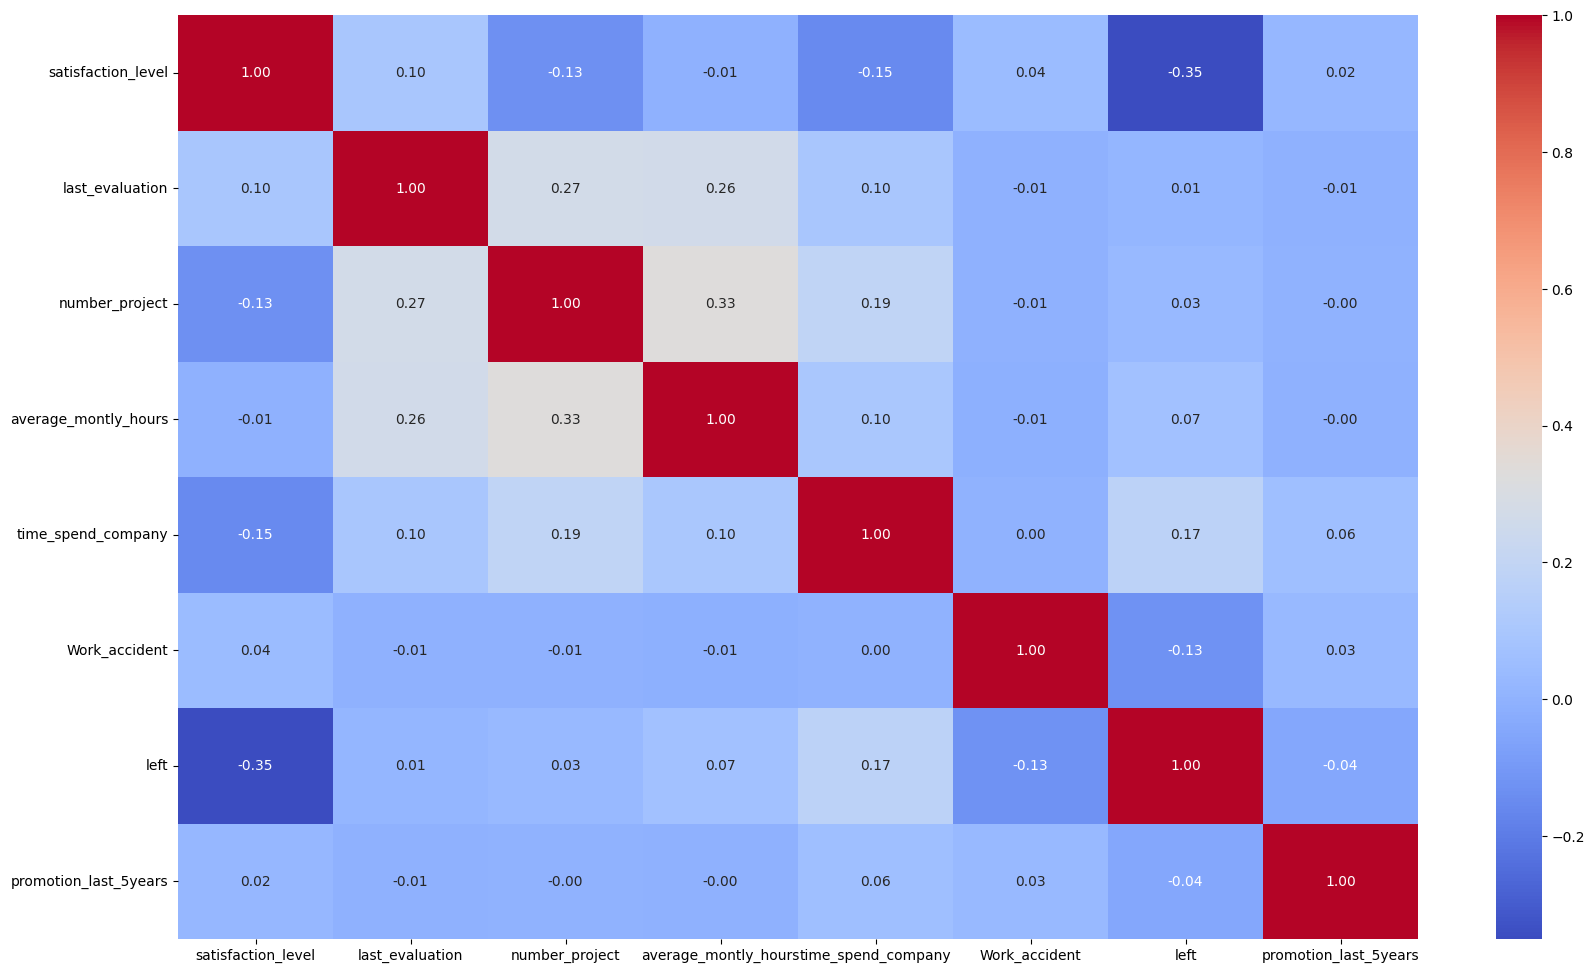

In [10]:
#  Generate a heatmap to illustrate the correlation between different pairs of variables
df = pd.DataFrame(data)
df = df.select_dtypes(include=['int64', 'float64'])
corr = df.corr()
plt.figure(figsize=(20,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

**2.2. Draw the distribution plot of:**

1.  Employee Satisfaction (use column satisfaction_level)
2.  Employee Evaluation (use column last_evaluation)
3.  Employee Average Monthly Hours (use column average_montly_hours)


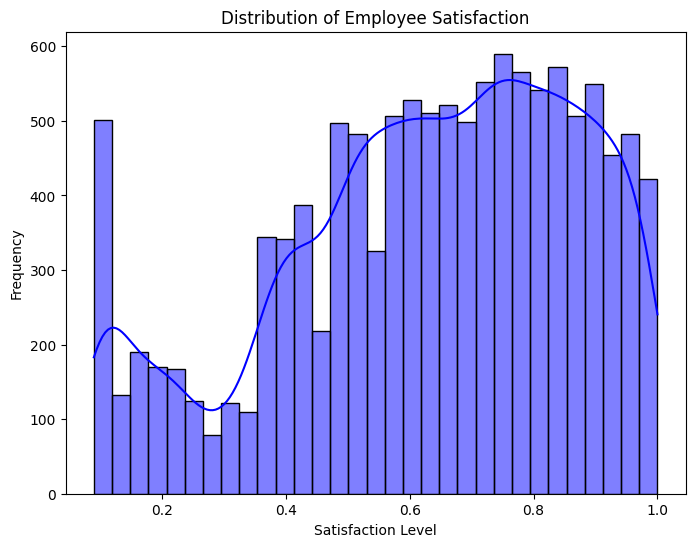

In [11]:
# Draw the distribution plot of: ■ Employee Satisfaction (use column satisfaction_level)
plt.figure(figsize=(8,6))
sns.histplot(df['satisfaction_level'], kde=True, color='blue')
plt.title('Distribution of Employee Satisfaction')
plt.xlabel('Satisfaction Level')
plt.ylabel('Frequency')
plt.show()

Text(0, 0.5, 'Frequency')

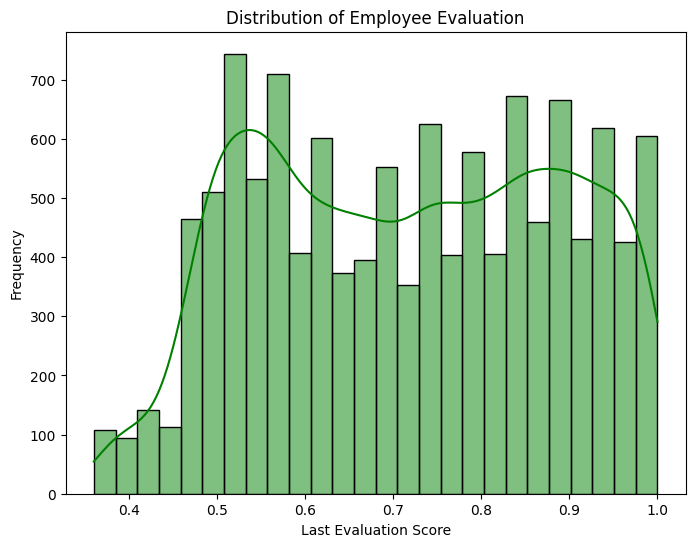

In [12]:
# Draw the distribution plot of ■ Employee Evaluation (use column last_evaluation)
plt.figure(figsize=(8,6))
sns.histplot(df['last_evaluation'], kde=True, color='green')
plt.title('Distribution of Employee Evaluation')
plt.xlabel('Last Evaluation Score')
plt.ylabel('Frequency')

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

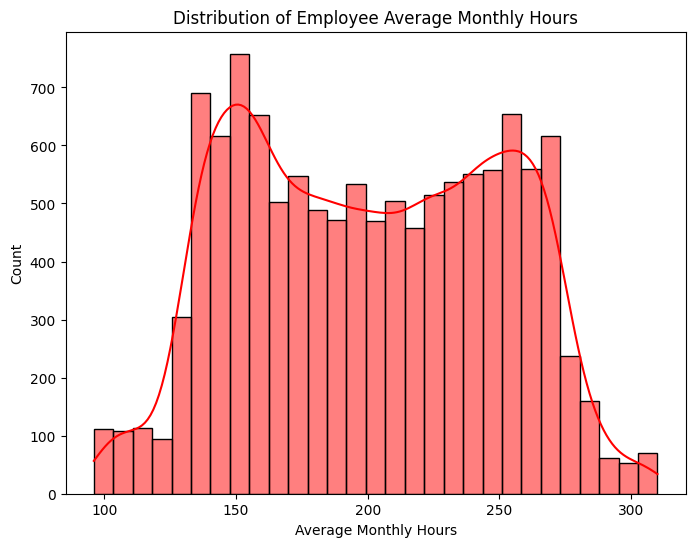

In [13]:
# Draw the distribution plot of: ■ Employee Average Monthly Hours (use column average_montly_hours)

plt.figure(figsize=(8,6))
sns.histplot(df['average_montly_hours'], kde=True, color='red')
plt.title('Distribution of Employee Average Monthly Hours')
plt.xlabel('Average Monthly Hours')
plt

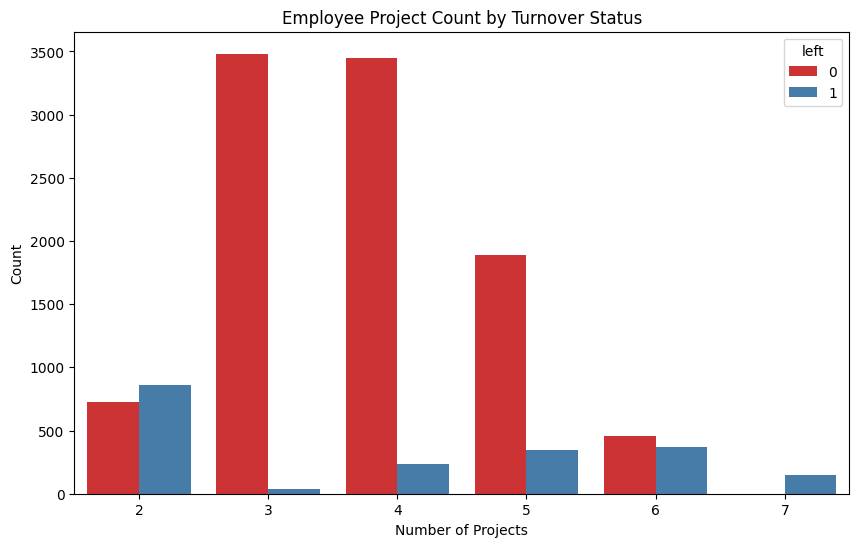

In [14]:
#Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.
plt.figure(figsize=(10,6))
sns.countplot(x='number_project', hue='left', data=df, palette='Set1')
plt.title('Employee Project Count by Turnover Status')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.show()

3. Perform clustering of employees who left based on their satisfaction and evaluation.

**3.1. Choose columns satisfaction_level, last_evaluation, and left.**

In [15]:
#separate features
features = data.iloc[:,[0,1,6]]

**3.2. Do K-means clustering of employees who left the company into 3 clusters?**

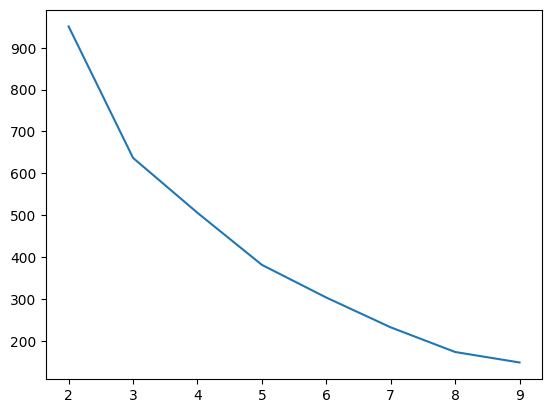

In [16]:
# 3.2. Do K-means clustering of employees who left the company into 3 clusters?
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss=[]
ss=[]
for i in range(2,10):
  modelToCheck = KMeans(n_clusters=i)
  modelToCheck.fit(features)
  wcss.append(modelToCheck.inertia_)
  label = modelToCheck.labels_
  ss.append(silhouette_score(features,label))

plt.plot(range(2,10),wcss)

Yes, we can take cluster as 3

In [17]:
#Model Building
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)

#Train model
model.fit(features)

#Predict groups
labelData = model.predict(features)
labelData

array([1, 1, 1, ..., 2, 0, 0], dtype=int32)

In [18]:
finalDataset = data.iloc[:,[0,1,6]]
finalDataset['category'] = labelData
finalDataset.head()

,satisfaction_level,last_evaluation,left,category
0,0.38,0.53,1,1
1,0.80,0.86,1,1
2,0.11,0.88,1,1
3,0.72,0.87,1,1
4,0.37,0.52,1,1


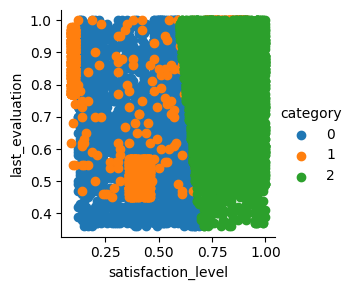

In [19]:
sns.FacetGrid(finalDataset, hue='category').map(plt.scatter, 'satisfaction_level','last_evaluation').add_legend()

category 2 or green category of employee who left the organization mostly at least satisfaction level (25% - 50%) and evaluation


**SMOTE TECHNIQUE**

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   sales                  11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


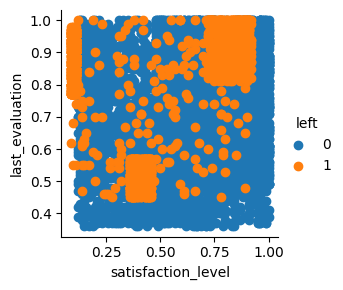

In [21]:
sns.FacetGrid(finalDataset, hue='left').map(plt.scatter, 'satisfaction_level','last_evaluation').add_legend()

Handle the left Class Imbalance using the SMOTE technique.
 Pre-process the data by converting categorical columns to numerical
 columns by:
 ■ Separating categorical variables and numeric variables
 ■ Applying get_dummies() to the categorical variables
 ■ Combining categorical variables and numeric variable

In [22]:
numericalColumns = data.select_dtypes(include=['int64', 'float64']).columns
categoricalColumns = data.select_dtypes(include=['object', 'category']).columns

categoricalColumnsAfterDummy = pd.get_dummies(data[categoricalColumns])
categoricalColumnsAfterDummy = categoricalColumnsAfterDummy.astype(int)
df_numerical = data[numericalColumns]
data_processed = pd.concat([categoricalColumnsAfterDummy, df_numerical], axis=1)
data_processed.head()

,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,...,salary_low,salary_medium,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
0,0,0,0,0,0,0,0,1,0,0,...,1,0,0.38,0.53,2,157,3,0,1,0
1,0,0,0,0,0,0,0,1,0,0,...,0,1,0.80,0.86,5,262,6,0,1,0
2,0,0,0,0,0,0,0,1,0,0,...,0,1,0.11,0.88,7,272,4,0,1,0
3,0,0,0,0,0,0,0,1,0,0,...,1,0,0.72,0.87,5,223,5,0,1,0
4,0,0,0,0,0,0,0,1,0,0,...,1,0,0.37,0.52,2,159,3,0,1,0


In [23]:
data_processed.left.value_counts()

,count
left,
0,10000
1,1991


**Do the stratified split of the dataset to train and test in the ratio 80:20**

In [24]:
# Separate the features and target
X = data_processed.drop(columns=['left'])
y = data_processed['left']

In [25]:
y


,left
0,1
1,1
2,1
3,1
4,1
...,...
11995,0
11996,0
11997,0
11998,0


In [26]:
#4.2. Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.
from sklearn.model_selection import train_test_split
# 4.2. Stratified split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=label,
                                                    random_state=123)

4.3 Upsample the train dataset using the SMOTE technique from the
imblearn module.

In [27]:
# Apply SMOTE
smote = SMOTE(random_state=123)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [28]:
# Combine the resampled features and target into a single dataframe
resampled_data = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=['left'])], axis=1)

In [29]:
resampled_data.left.value_counts()

,count
left,
0,8000
1,8000


In [30]:
resampled_data.head(5)

,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,...,salary_low,salary_medium,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,left
0,0,0,0,0,0,0,0,1,0,0,...,1,0,0.82,0.88,4,149,2,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,1,0,0.10,0.80,7,292,5,0,0,1
2,0,0,0,0,0,1,0,0,0,0,...,0,1,0.30,0.53,3,210,6,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,1,0,0.66,0.51,3,192,3,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,1,0.20,0.98,4,166,4,1,0,0


Now **left** is balanced data set


**Perform 5-fold cross-validation model training and evaluate performance.**

5.1. Train a logistic regression model, apply a 5-fold CV, and plot the classification report

In [31]:
from sklearn.linear_model import LogisticRegression

# Separate the features and target
features = resampled_data.drop(columns=['left'])
label = resampled_data['left']

for rs in range(123,199):

  X_train,X_test,y_train,y_test = train_test_split(features,
                                                    label,
                                                    test_size=0.2,
                                                    random_state=rs)
  # Train a logistic regression model
  model = LogisticRegression(max_iter=1000, random_state=rs)
  model.fit(X_train,y_train)
  trainScore = model.score(X_train,y_train)
  testScore = model.score(X_test,y_test)
  if(testScore > trainScore):
    print(f"TestScore is {testScore}, trainScore is {trainScore}")
    print(f"Random State is {rs}")

TestScore is 0.854375, trainScore is 0.851796875
Random State is 126
TestScore is 0.8596875, trainScore is 0.849296875
Random State is 127
TestScore is 0.8515625, trainScore is 0.85
Random State is 129
TestScore is 0.86375, trainScore is 0.850234375
Random State is 130
TestScore is 0.8609375, trainScore is 0.849921875
Random State is 133
TestScore is 0.864375, trainScore is 0.84921875
Random State is 134
TestScore is 0.8559375, trainScore is 0.85328125
Random State is 135
TestScore is 0.8621875, trainScore is 0.85
Random State is 136
TestScore is 0.8609375, trainScore is 0.853359375
Random State is 139
TestScore is 0.8528125, trainScore is 0.850625
Random State is 140
TestScore is 0.8575, trainScore is 0.85125
Random State is 141
TestScore is 0.8540625, trainScore is 0.85
Random State is 144
TestScore is 0.8590625, trainScore is 0.851953125
Random State is 148
TestScore is 0.854375, trainScore is 0.8540625
Random State is 149
TestScore is 0.853125, trainScore is 0.852734375
Random Stat

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X_train,X_test,y_train,y_test = train_test_split(features,
                                                    label,
                                                    test_size=0.2,
                                                    random_state=149)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000, random_state=149)
model.fit(X_train,y_train)
trainScore = model.score(X_train,y_train)
testScore = model.score(X_test,y_test)

#Apply a 5-fold CV
scores = cross_val_score(model,
                         features,
                         label,
                         cv=5)
print(scores)
print(scores.mean())
print(scores.min())
print(scores.max())

[0.69125   0.874375  0.885625  0.8815625 0.8825   ]
0.8430625
0.69125
0.885625


In [33]:
print(f"TestScore is {testScore}, trainScore is {trainScore}")

TestScore is 0.854375, trainScore is 0.8540625


In [34]:
#Classification Report ---> Entire Dataset
from sklearn.metrics import classification_report
print(classification_report(label,model.predict(features)))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      8000
           1       0.86      0.85      0.85      8000

    accuracy                           0.85     16000
   macro avg       0.85      0.85      0.85     16000
weighted avg       0.85      0.85      0.85     16000



**5.2. Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.**

In [58]:
from sklearn.ensemble import RandomForestClassifier

for rs in range(123,199):

  X_train,X_test,y_train,y_test = train_test_split(features,
                                                    label,
                                                    test_size=0.2,
                                                    random_state=rs)
  # Train a logistic regression model
  model = RandomForestClassifier(random_state=rs)
  model.fit(X_train,y_train)
  trainScore = model.score(X_train,y_train)
  testScore = model.score(X_test,y_test)
  print(f"TestScore is {testScore}, trainScore is {trainScore}")
  print(f"Random State is {rs}")

TestScore is 0.9759375, trainScore is 1.0
Random State is 123
TestScore is 0.9778125, trainScore is 1.0
Random State is 124
TestScore is 0.979375, trainScore is 1.0
Random State is 125
TestScore is 0.9778125, trainScore is 1.0
Random State is 126
TestScore is 0.9778125, trainScore is 1.0
Random State is 127
TestScore is 0.9834375, trainScore is 1.0
Random State is 128
TestScore is 0.9784375, trainScore is 1.0
Random State is 129
TestScore is 0.9775, trainScore is 0.999921875
Random State is 130
TestScore is 0.98, trainScore is 1.0
Random State is 131
TestScore is 0.9775, trainScore is 1.0
Random State is 132
TestScore is 0.9796875, trainScore is 1.0
Random State is 133
TestScore is 0.9778125, trainScore is 1.0
Random State is 134
TestScore is 0.976875, trainScore is 1.0
Random State is 135
TestScore is 0.9821875, trainScore is 1.0
Random State is 136
TestScore is 0.9740625, trainScore is 1.0
Random State is 137
TestScore is 0.9740625, trainScore is 1.0
Random State is 138
TestScore is 

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Separate the features and target
features = resampled_data.drop(columns=['left'])
label = resampled_data['left']

X_train,X_test,y_train,y_test = train_test_split(features,
                                                   label,
                                                   test_size=0.2,
                                                   random_state=182)
# Train a Random Forest Classifier model
model = RandomForestClassifier(random_state=182)
model.fit(X_train,y_train)
trainScore = model.score(X_train,y_train)
testScore = model.score(X_test,y_test)

#Apply a 5-fold CV
scores = cross_val_score(model,
                         features,
                         label,
                         cv=5)
print(scores)
print(scores.mean())
print(scores.min())
print(scores.max())

[0.9521875 0.9825    0.985     0.9815625 0.98375  ]
0.977
0.9521875
0.985


In [60]:
print(f"TestScore is {testScore}, trainScore is {trainScore}")

TestScore is 0.9809375, trainScore is 1.0


In [61]:
#Classification Report ---> Entire Dataset
from sklearn.metrics import classification_report
print(classification_report(label,model.predict(features)))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8000
           1       1.00      0.99      1.00      8000

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



Train a Gradient Boosting Classifier model, apply the 5-fold CV, and
plot the classification report

In [68]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Separate the features and target
features = resampled_data.drop(columns=['left'])
label = resampled_data['left']

X_train,X_test,y_train,y_test = train_test_split(features,
                                                   label,
                                                   test_size=0.2,
                                                   random_state=200)
# Train a GradientBoosting Classifier model
model = GradientBoostingClassifier(random_state=200, n_estimators=1, learning_rate=1.0)
model.fit(X_train,y_train)
trainScore = model.score(X_train,y_train)
testScore = model.score(X_test,y_test)

#Apply a 5-fold CV
scores = cross_val_score(model,
                         features,
                         label,
                         cv=5)
print(scores)
print(scores.mean())
print(scores.min())

[0.914375  0.925625  0.9290625 0.92      0.9246875]
0.92275
0.914375


In [69]:
print(f"TestScore is {testScore}, trainScore is {trainScore}")

TestScore is 0.9253125, trainScore is 0.92484375


In [70]:
#Classification Report ---> Entire Dataset
from sklearn.metrics import classification_report
print(classification_report(label,model.predict(features)))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92      8000
           1       0.91      0.94      0.93      8000

    accuracy                           0.92     16000
   macro avg       0.93      0.92      0.92     16000
weighted avg       0.93      0.92      0.92     16000



6. Identify the best model and justify the evaluation metrics used.
  1. Find the ROC/AUC for each model and plot the ROC curve.
  2. Find the confusion matrix for each of the models.
  3. Explain which metric needs to be used from the confusion matrix:
  Recall or Precision?





**Find the ROC/AUC for each model and plot the ROC curve**

**ROC/AUC for LogisticRegression model and plot the ROC curve**

In [42]:
# Separate the features and target
features = resampled_data.drop(columns=['left'])
label = resampled_data['left']

In [71]:
# ROC/AUC for LogisticRegression model and plot the ROC curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train,X_test,y_train,y_test = train_test_split(features,
                                                 label,
                                                 test_size=0.2,
                                                 random_state=149)
# Train a logistic regression model
model = LogisticRegression(max_iter=1000, random_state=149)

model.fit(X_train,y_train)

#Evaluation
# 1. Test for generalization

print("Logistic Regression model Testing Score is {} and Training Score is {} ".format(model.score(X_test,y_test) , model.score(X_train,y_train)))

Logistic Regression model Testing Score is 0.854375 and Training Score is 0.8540625 


In [72]:
#ROC Curve
model.predict(X_test)
model.predict_proba(X_test)

array([[0.90148786, 0.09851214],
       [0.38852339, 0.61147661],
       [0.92336007, 0.07663993],
       ...,
       [0.96448364, 0.03551636],
       [0.73946382, 0.26053618],
       [0.38776426, 0.61223574]])

0.9274621562155785


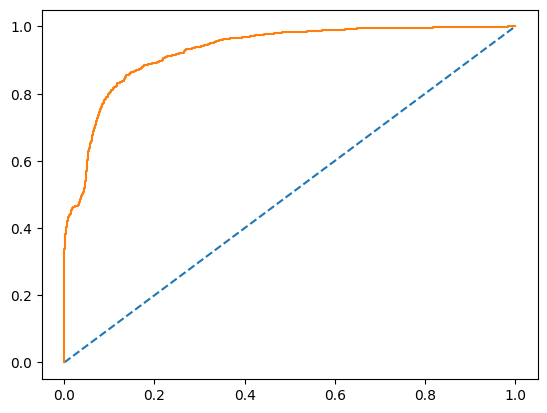

In [74]:
#Plot ROC
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
%matplotlib inline
#Step1:  Extract the prob value of 1
probabilityValues = model.predict_proba(X_test)[:,1]

#Step2: Calc AUC
auc = roc_auc_score(y_test,probabilityValues)

#Step3: Plot Skill Line (0,0)(1,1)
plt.plot([0,1],[0,1],linestyle="--")

#Step4: Plot ROC
fpr,tpr,_ = roc_curve(y_test,probabilityValues)
plt.plot(fpr,tpr)
print(auc)

In [75]:
#Code to create Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(label,model.predict(features))

array([[6886, 1114],
       [1220, 6780]])

In [76]:
#Classification Report ---> Entire Dataset
from sklearn.metrics import classification_report
print(classification_report(label,model.predict(features)))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      8000
           1       0.86      0.85      0.85      8000

    accuracy                           0.85     16000
   macro avg       0.85      0.85      0.85     16000
weighted avg       0.85      0.85      0.85     16000



**ROC/AUC for Random Classifier model and plot the ROC curve**

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train,X_test,y_train,y_test = train_test_split(features,
                                                 label,
                                                 test_size=0.2,
                                                 random_state=182)

model=RandomForestClassifier(random_state=182)
model.fit(X_train,y_train)

#Evaluation
# 1. Test for generalization

print("Testing Score is {} and Training Score is {} ".format(model.score(X_test,y_test) , model.score(X_train,y_train)))

Testing Score is 0.9809375 and Training Score is 1.0 


In [78]:
#ROC Curve
model.predict(X_test)
model.predict_proba(X_test)

array([[0.98, 0.02],
       [1.  , 0.  ],
       [0.99, 0.01],
       ...,
       [0.99, 0.01],
       [0.  , 1.  ],
       [0.  , 1.  ]])

0.998480383271559


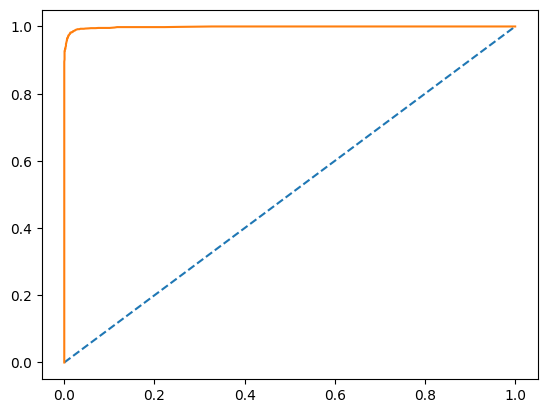

In [79]:
#Step1:  Extract the prob value of 1
probabilityValues = model.predict_proba(X_test)[:,1]

#Step2: Calc AUC
auc = roc_auc_score(y_test,probabilityValues)

#Step3: Plot Skill Line (0,0)(1,1)
plt.plot([0,1],[0,1],linestyle="--")

#Step4: Plot ROC
fpr,tpr,_ = roc_curve(y_test,probabilityValues)
plt.plot(fpr,tpr)
print(auc)

In [80]:
#Code to create Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(label,model.predict(features))

array([[7987,   13],
       [  48, 7952]])

In [52]:
#Classification Report ---> Entire Dataset
from sklearn.metrics import classification_report
print(classification_report(label,model.predict(features)))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8000
           1       1.00      0.99      1.00      8000

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



**The ROC curve is above the skillline, so approve model.**

**ROC/AUC for Gradient Boosting Classifier model and plot the ROC curve**

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

for rs in range(1,199):

  X_train,X_test,y_train,y_test = train_test_split(features,
                                                  label,
                                                  test_size=0.2,
                                                  random_state=200)

model=GradientBoostingClassifier(random_state=200, n_estimators=1, learning_rate=1.0)
model.fit(X_train,y_train)

#Evaluation
# 1. Test for generalization

print("Testing Score is {} and Training Score is {} ".format(model.score(X_test,y_test) , model.score(X_train,y_train)))

Testing Score is 0.9253125 and Training Score is 0.92484375 


In [83]:
#ROC Curve
model.predict(X_test)

model.predict_proba(X_test)

array([[0.16202822, 0.83797178],
       [0.16202822, 0.83797178],
       [0.85832112, 0.14167888],
       ...,
       [0.16202822, 0.83797178],
       [0.16202822, 0.83797178],
       [0.16202822, 0.83797178]])

0.9280871001046505


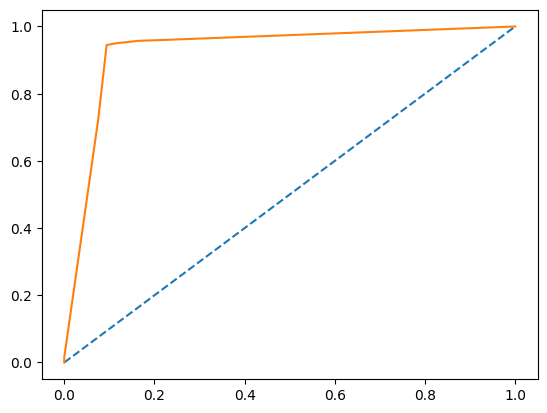

In [84]:
#Step1:  Extract the prob value of 1
probabilityValues = model.predict_proba(X_test)[:,1]

#Step2: Calc AUC
auc = roc_auc_score(y_test,probabilityValues)

#Step3: Plot Skill Line (0,0)(1,1)
plt.plot([0,1],[0,1],linestyle="--")

#Step4: Plot ROC
fpr,tpr,_ = roc_curve(y_test,probabilityValues)
plt.plot(fpr,tpr)
print(auc)

In [85]:
#Code to create Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(label,model.predict(features))

array([[7259,  741],
       [ 460, 7540]])

In [86]:
#Classification Report ---> Entire Dataset
from sklearn.metrics import classification_report
print(classification_report(label,model.predict(features)))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92      8000
           1       0.91      0.94      0.93      8000

    accuracy                           0.92     16000
   macro avg       0.93      0.92      0.92     16000
weighted avg       0.93      0.92      0.92     16000



6.3 Explain which metric needs to be used from the confusion matrix:
Recall or Precision?

In [87]:
# Based on confusion matrix, Random Classifier model to be used

**Based on confusion matrix, Random Classifier model to be used.**

7. Suggest various retention strategies for targeted employees.


In [93]:
#7.1. Using the best model, predict the probability of employee turnover in the test data.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train,X_test,y_train,y_test = train_test_split(features,
                                                 label,
                                                 test_size=0.2,
                                                 random_state=182)

model=RandomForestClassifier(random_state=182)
model.fit(X_train,y_train)

#Evaluation
# 1. Test for generalization


# Predict probabilities of employee turnover on the test data
y_pred_proba_best_model = model.predict_proba(X_test)

# Extract probabilities of employee leaving (usually second column in binary classification)
probabilities = y_pred_proba_best_model[:, 1]
print(probabilities)

[0.02 0.   0.01 ... 0.01 1.   1.  ]


In [92]:
#7.2. Based on the probability score range below, categorize the
# employees into four zones and suggest your thoughts on the
# retention strategies for each zone.
# ■ Safe Zone (Green) (Score < 20%)
# ■ Low-Risk Zone (Yellow) (20% < Score < 60%)
# ■ Medium-Risk Zone (Orange) (60% < Score < 90%)
# ■ High-Risk Zone (Red) (Score > 90%)
# Create a function to categorize employees based on probability scores
def categorize_zone(probability):
    if probability < 0.2:
        return 'Safe Zone (Green)'
    elif 0.2 <= probability < 0.6:
        return 'Low-Risk Zone (Yellow)'
    elif 0.6 <= probability < 0.9:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

# Apply the function to categorize all employees in the test data
zones = [categorize_zone(p) for p in probabilities]

# Add these zones to the test dataset
X_test['Risk Zone'] = zones

# Display a sample of categorized employees
print(X_test[['Risk Zone']].head())

                  Risk Zone
9048      Safe Zone (Green)
7819      Safe Zone (Green)
1907      Safe Zone (Green)
6007      Safe Zone (Green)
12698  High-Risk Zone (Red)


Retention Strategies for Each Zone
1. Safe Zone (Green) (Score < 20%):
These employees are satisfied with their work environment, and the risk of them leaving is very low.
Strategies:
Continue recognizing their contributions.
Provide growth opportunities (upskilling, career development).
Ensure open communication channels so they feel heard and valued.
2. Low-Risk Zone (Yellow) (20% < Score < 60%):
These employees may have slight dissatisfaction but are not in immediate danger of leaving.
Strategies:
Conduct one-on-one meetings to discuss their job satisfaction and address concerns.
Offer role variety or challenging projects to re-engage them.
Encourage a healthy work-life balance.
3. Medium-Risk Zone (Orange) (60% < Score < 90%):
Employees in this group are at a moderate risk of leaving. Dissatisfaction may be more pronounced.
Strategies:
Immediate interventions are required, such as addressing specific concerns (compensation, workload, management style).
Provide personalized career paths and mentorship opportunities to align their goals with the company.
Consider offering incentives like bonuses, additional time off, or flexible working arrangements.
4. High-Risk Zone (Red) (Score > 90%):
These employees are very likely to leave the company and need urgent attention.
Strategies:
Engage in direct conversations to understand their reasons for wanting to leave.
Address any major issues (e.g., conflicts, dissatisfaction with management or pay).
Explore retention bonuses or promotions, but only if it aligns with company policy.
If leaving seems inevitable, prepare succession plans and identify potential replacements to mitigate the impact.